In [86]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [87]:
DATA_DIR = Path("../data/raw")

train_transaction_path = DATA_DIR / "train_transaction.csv"
train_identity_path = DATA_DIR / "train_identity.csv"

print(train_transaction_path)
print(train_identity_path)

..\data\raw\train_transaction.csv
..\data\raw\train_identity.csv


In [88]:
for file in DATA_DIR.iterdir():
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"{file.name:30} {size_mb:,.1f} MB")

sample_submission.csv          5.8 MB
test_identity.csv              24.6 MB
test_transaction.csv           584.8 MB
train_identity.csv             25.3 MB
train_transaction.csv          651.7 MB


In [89]:
train_sample = pd.read_csv(
    train_transaction_path,
    nrows = 10_000
)

train_sample.shape

(10000, 394)

In [90]:
train_sample.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [91]:
train_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 30.1 MB


In [92]:
train_sample["isFraud"].value_counts()

isFraud
0    9735
1     265
Name: count, dtype: int64

In [93]:
train_sample["isFraud"].value_counts(normalize= True)

isFraud
0    0.9735
1    0.0265
Name: proportion, dtype: float64

In [94]:
# Fraud rate
fraud_rate = train_sample["isFraud"].mean()

print(f"Fraud rate: {fraud_rate:.2%}")

Fraud rate: 2.65%


In [95]:
# Transaction time range
print("TransactionDT minimum:", train_sample["TransactionDT"].min())
print("TransactionDT maximum:", train_sample["TransactionDT"].max())

TransactionDT minimum: 86400
TransactionDT maximum: 313121


In [96]:
# Check whether TransactionDT is ordered
is_sorted = train_sample["TransactionDT"].is_monotonic_increasing

print("TransactionDT sorted:", is_sorted)

TransactionDT sorted: True


In [97]:
pd.set_option("display.max_rows", 400)

print(train_sample.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

In [98]:
# Missing values by column

missing = train_sample.isna().sum().sort_values(ascending = False)

missing_percentage = (
    train_sample.isna().mean() * 100
).sort_values(ascending = False)

missing_sumamry = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

missing_sumamry.head(30)

,missing_count,missing_percentage
D7,9777,97.77
D13,9720,97.20
dist2,9622,96.22
D12,9594,95.94
D14,9550,95.50
D6,9509,95.09
D8,8900,89.00
D9,8900,89.00
V152,8618,86.18
V142,8618,86.18


In [99]:
(train_sample.isna().all()).sum()

np.int64(0)

In [100]:
(missing_percentage > 50).sum()

np.int64(208)

In [101]:
(missing_percentage > 90).sum()

np.int64(6)

In [102]:
train_sample.groupby("isFraud")["D7"].apply(lambda x: x.isna().mean() * 100)

isFraud
0    97.925013
1    92.075472
Name: D7, dtype: float64

In [103]:
train_sample["D7_missing"] = train_sample["D7"].isna().astype(int)

C:\Users\niles\AppData\Local\Temp\ipykernel_13600\3803323638.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_sample["D7_missing"] = train_sample["D7"].isna().astype(int)


In [104]:
train_sample = train_sample.drop(columns=["D7_missing"])

In [105]:
high_missing_cols = missing_percentage[missing_percentage > 90].index

high_missing_cols

Index(['D7', 'D13', 'dist2', 'D12', 'D14', 'D6'], dtype='str')

In [106]:
for col in high_missing_cols:
    fraud_missing_rate= (
        train_sample.groupby("isFraud")[col]
        .apply(lambda x: x.isna().mean() * 100)
    )

    print(f"\n{col}")
    print(fraud_missing_rate)


D7
isFraud
0    97.925013
1    92.075472
Name: D7, dtype: float64

D13
isFraud
0    97.298408
1    93.584906
Name: D13, dtype: float64

dist2
isFraud
0    96.281459
1    93.962264
Name: dist2, dtype: float64

D12
isFraud
0    96.147920
1    88.301887
Name: D12, dtype: float64

D14
isFraud
0    95.839753
1    83.018868
Name: D14, dtype: float64

D6
isFraud
0    95.285054
1    87.924528
Name: D6, dtype: float64


In [107]:
# Find the columns where more than 90% of values are missing
high_missing_cols = missing_percentage[missing_percentage > 90].index

# Empty list to store our results
missingness_by_fraud = []

# Check each highly-missing column
for col in high_missing_cols:
    # Calculate the percantage of missing values separately for legitmate(0) and fraud(1) transactions
    missing_by_target = (
        train_sample.groupby("isFraud")[col]
        .apply(lambda x: x.isna().mean() * 100)
    )

    missingness_by_fraud.append({
    "feature": col,
    "legitmate_missing_%": missing_by_target.get(0,0),
    "fraud_missing_%": missing_by_target.get(1,0)

    })

#Convert our list of dictionaries into a DataFrame
missingness_comparision = pd.DataFrame(missingness_by_fraud)

# Difference in missingness between legitmate and fraudulent transactions
missingness_comparision["difference_pp"] = (
    missingness_comparision["legitmate_missing_%"] - missingness_comparision["fraud_missing_%"]
)

# Sort by largest difference
missingness_comparision.sort_values(
    "difference_pp", ascending= False
)



,feature,legitmate_missing_%,fraud_missing_%,difference_pp
4,D14,95.839753,83.018868,12.820886
3,D12,96.147920,88.301887,7.846033
5,D6,95.285054,87.924528,7.360526
0,D7,97.925013,92.075472,5.849541
1,D13,97.298408,93.584906,3.713502
2,dist2,96.281459,93.962264,2.319195


### Missingness and Fraud

Several highly-missing features show different missingness patterns between
legitimate and fraudulent transactions.

Among features with more than 90% missing values, D14 shows the largest
difference: approximately 95.84% of legitimate transactions have D14 missing,
compared with 83.02% of fraudulent transactions.

This suggests that missingness itself may contain predictive information.
Therefore, highly-missing features should not automatically be removed solely
because of their missing-value percentage. During feature engineering, we will
evaluate whether missingness indicators improve fraud detection performance.

These observations are based on an initial 10,000-row sample and will need to
be validated on the full training dataset.

In [108]:
# Count how many transactions belong to each ProductCD category
product_counts = train_sample["ProductCD"].value_counts()

# Display the number of transactions in each category
product_counts

ProductCD
W    7709
C     906
H     871
R     305
S     209
Name: count, dtype: int64

In [109]:
# Calculate the number of transactions in each ProductCD category
product_summary = train_sample.groupby("ProductCD").agg(
    transactions = ("isFraud", "count"),
    fraud_count=("isFraud", "sum")
)

# Calculate the percentage of fraudelent transactions within each ProductCD category
product_summary["fraud_rate_%"] = (
    product_summary["fraud_count"]/product_summary["transactions"] * 100
)

#Sort categories by highest to lowest fraud rate
product_summary.sort_values(
    "fraud_rate_%", ascending= False
)

,transactions,fraud_count,fraud_rate_%
ProductCD,,,
C,906,94,10.375276
R,305,17,5.573770
S,209,10,4.784689
W,7709,132,1.712284
H,871,12,1.377727


In [110]:
# Calculate what percentage of all fraud cases comes from each ProductCD category
product_summary["share_of_all_fraud_%"] = (
    product_summary["fraud_count"]/product_summary["fraud_count"].sum() * 100
)

# Updated summary
product_summary.sort_values(
    "fraud_count", ascending= False
)

,transactions,fraud_count,fraud_rate_%,share_of_all_fraud_%
ProductCD,,,,
W,7709,132,1.712284,49.811321
C,906,94,10.375276,35.471698
R,305,17,5.573770,6.415094
H,871,12,1.377727,4.528302
S,209,10,4.784689,3.773585


In [111]:
# Count number of transactions belonging to each card4 category to understand the distribution before calculating fraud rates.
card4_counts = train_sample["card4"].value_counts(dropna=False)

# Display the counts
card4_counts

card4
visa                6209
mastercard          3586
american express     112
discover              92
NaN                    1
Name: count, dtype: int64

In [112]:
# Group transactions by card4 category and count total transactions and fraudulent transactions.
card4_summary = train_sample.groupby("card4", dropna=False).agg( 
    transactions=("isFraud", "count"),
    fraud_count=("isFraud", "sum")
) # Use dropna False to appear missing value as its own category

# Percentage of transactions that are fraudulent within each card4 category.
card4_summary["fraud_rate_%"] = (
    card4_summary["fraud_count"]
    / card4_summary["transactions"]
    * 100
)

# Sort from the highest fraud rate to the lowest.
card4_summary.sort_values(
    "fraud_rate_%",
    ascending=False
)


,transactions,fraud_count,fraud_rate_%
card4,,,
mastercard,3586,117,3.262688
discover,92,3,3.260870
visa,6209,143,2.303108
american express,112,2,1.785714
NaN,1,0,0.000000


In [113]:
# Count transactions for each card6 category.
card6_counts = train_sample["card6"].value_counts(
    dropna=False
)

card6_counts

card6
debit     7891
credit    2108
NaN          1
Name: count, dtype: int64

In [114]:
# Group transactions by card6 category.
# We keep missing values as a separate category.
card6_summary = train_sample.groupby("card6", dropna=False).agg(
    transactions=("isFraud", "count"),

    # Because isFraud is 0 or 1, summing it gives
    # the total number of fraudulent transactions.
    fraud_count=("isFraud", "sum")
)

# Calculate the percentage of transactions that are fraudulent
# within each card6 category.
card6_summary["fraud_rate_%"] = (
    card6_summary["fraud_count"]
    / card6_summary["transactions"]
    * 100
)

# Sort categories from highest to lowest fraud rate.
card6_summary.sort_values(
    "fraud_rate_%",
    ascending=False
)

,transactions,fraud_count,fraud_rate_%
card6,,,
credit,2108,150,7.115750
debit,7891,115,1.457356
NaN,1,0,0.000000


In [115]:
def analyze_categorical_feature(data, column, min_transactions=10):
    """
    Analyze a categorical feature by calculating:
    - number of transactions
    - number of fraud cases
    - fraud rate
    - share of all fraud cases

    Categories with fewer than min_transactions are excluded
    from the final results to avoid interpreting very small groups.
    """

    # Group transactions by the selected categorical feature.
    # dropna=False keeps missing values visible.
    summary = data.groupby(column, dropna=False).agg(
        transactions=("isFraud", "count"),

        # isFraud contains 0 and 1.
        # Summing it gives the number of fraudulent transactions.
        fraud_count=("isFraud", "sum")
    )

    # Calculate the percentage of transactions that are fraudulent
    # within each category.
    summary["fraud_rate_%"] = (
        summary["fraud_count"]
        / summary["transactions"]
        * 100
    )

    # Calculate each category's contribution to all fraud cases.
    summary["share_of_all_fraud_%"] = (
        summary["fraud_count"]
        / summary["fraud_count"].sum()
        * 100
    )

    # Keep only categories with enough observations.
    # This prevents tiny groups from producing misleadingly high rates.
    summary = summary[
        summary["transactions"] >= min_transactions
    ]

    # Sort from highest to lowest fraud rate.
    summary = summary.sort_values(
        "fraud_rate_%",
        ascending=False
    )

    # Return the completed summary.
    return summary

In [116]:
# Analyze card6 using our reusable function.
card6_analysis = analyze_categorical_feature(
    train_sample,
    "card6"
)

# Display the result.
card6_analysis

,transactions,fraud_count,fraud_rate_%,share_of_all_fraud_%
card6,,,,
credit,2108,150,7.115750,56.603774
debit,7891,115,1.457356,43.396226


In [117]:
# Count the email-domain categories.
# dropna=False lets us see how many transactions have no
# purchaser email domain recorded.
email_counts = train_sample["P_emaildomain"].value_counts(
    dropna=False
)

# Show the 20 most common categories.
email_counts.head(20)

P_emaildomain
gmail.com        3677
NaN              2105
yahoo.com        1726
hotmail.com       633
anonymous.com     490
aol.com           418
comcast.net       153
icloud.com         98
outlook.com        84
msn.com            59
att.net            53
charter.net        51
sbcglobal.net      50
verizon.net        49
ymail.com          44
live.com           43
me.com             31
bellsouth.net      31
yahoo.com.mx       23
cox.net            18
Name: count, dtype: int64

In [118]:
# Analyze fraud rate for each purchaser email domain.
# We use the function we created earlier so that we get:
# - number of transactions
# - number of fraud cases
# - fraud rate
# - share of all fraud cases
#
# min_transactions=20 removes very small domains from the displayed
# results because their fraud rates can be unstable.
email_analysis = analyze_categorical_feature(
    train_sample,
    "P_emaildomain",
    min_transactions=20
)

email_analysis

,transactions,fraud_count,fraud_rate_%,share_of_all_fraud_%
P_emaildomain,,,,
outlook.com,84,12,14.285714,4.528302
ymail.com,44,4,9.090909,1.509434
hotmail.com,633,32,5.055292,12.075472
icloud.com,98,4,4.081633,1.509434
me.com,31,1,3.225806,0.377358
gmail.com,3677,118,3.209138,44.528302
NaN,2105,48,2.280285,18.113208
aol.com,418,9,2.153110,3.396226
anonymous.com,490,10,2.040816,3.773585


In [119]:
# Analyze fraud rates for recipient email domains.
# We use the same minimum transaction threshold so that
# very small categories do not dominate our interpretation.
r_email_analysis = analyze_categorical_feature(
    train_sample,
    "R_emaildomain",
    min_transactions=20
)

r_email_analysis

,transactions,fraud_count,fraud_rate_%,share_of_all_fraud_%
R_emaildomain,,,,
outlook.com,64,12,18.750000,4.528302
gmail.com,642,77,11.993769,29.056604
hotmail.com,346,22,6.358382,8.301887
yahoo.com,124,6,4.838710,2.264151
anonymous.com,233,4,1.716738,1.509434
NaN,8375,140,1.671642,52.830189
comcast.net,31,0,0.000000,0.000000
aol.com,22,0,0.000000,0.000000
yahoo.com.mx,23,0,0.000000,0.000000


In [120]:
# Get basic statistics for transaction amount.
# This helps us understand the typical transaction size,
# the spread of values, and whether there are extreme outliers.
train_sample["TransactionAmt"].describe()

count    10000.000000
mean       131.532165
std        215.136534
min          1.896000
25%         44.000000
50%         74.950000
75%        131.058000
max       3247.910000
Name: TransactionAmt, dtype: float64

In [121]:
# Compare transaction amounts between legitimate and fraudulent transactions.
# This lets us see whether fraud tends to occur at different
# transaction amounts in our initial sample.
train_sample.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,9735.0,131.034187,215.149402,1.896,44.000,72.990,130.5,3247.91
1,265.0,149.825823,214.265761,5.000,48.336,83.742,159.0,2161.00


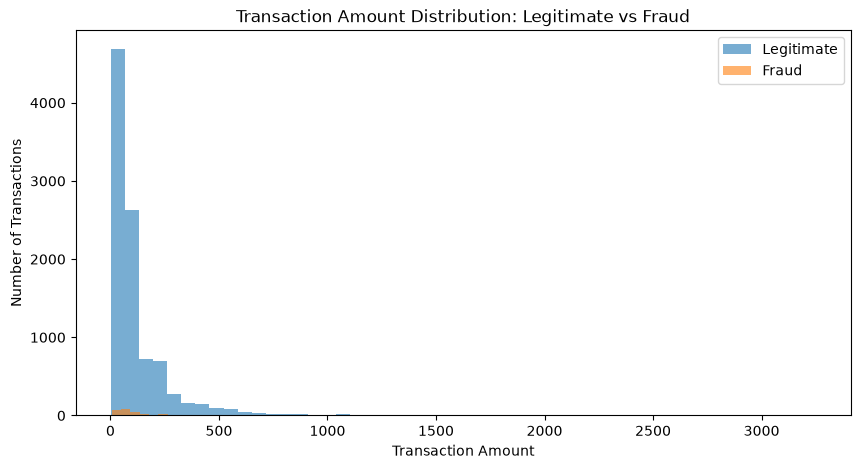

In [122]:
# Separate transaction amounts into legitimate and fraudulent transactions.
# This allows us to compare their distributions directly.
legit_amounts = train_sample.loc[
    train_sample["isFraud"] == 0,
    "TransactionAmt"
]

fraud_amounts = train_sample.loc[
    train_sample["isFraud"] == 1,
    "TransactionAmt"
]

# Create a histogram for legitimate transactions.
# Histograms show how frequently different transaction amounts occur.
plt.figure(figsize=(10, 5))

plt.hist(
    legit_amounts,
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    fraud_amounts,
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution: Legitimate vs Fraud")
plt.legend()
plt.show()

In [ ]:
# Divide transaction amounts into ranges so we can compare the fraud rate across different transaction sizes.
# Each transaction will be assigned to one of these amount bins.
amount_bins = [0, 25, 50, 100, 200, 500, 1000, 5000]

train_sample["amount_bin"] = pd.cut(
    train_sample["TransactionAmt"],
    bins=amount_bins,
    include_lowest=True
)

# Calculate the number of transactions and fraud cases
# within each transaction-amount range.
amount_analysis = train_sample.groupby(
    "amount_bin",
    observed=False
).agg(
    transactions=("isFraud", "count"),
    fraud_count=("isFraud", "sum")
)

# Calculate the percentage of transactions that are fraudulent
# within each amount range.
amount_analysis["fraud_rate_%"] = (
    amount_analysis["fraud_count"]
    / amount_analysis["transactions"]
    * 100
)

amount_analysis

C:\Users\niles\AppData\Local\Temp\ipykernel_13600\2565616968.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_sample["amount_bin"] = pd.cut(


,transactions,fraud_count,fraud_rate_%
amount_bin,,,
"(-0.001, 25.0]",962,30,3.118503
"(25.0, 50.0]",2672,49,1.833832
"(50.0, 100.0]",2814,85,3.020611
"(100.0, 200.0]",2011,52,2.585778
"(200.0, 500.0]",1198,34,2.838063
"(500.0, 1000.0]",246,13,5.284553
"(1000.0, 5000.0]",97,2,2.061856


In [124]:
# Remove the temporary amount-bin column.
# We created it only to investigate the relationship between
# transaction amount and fraud rate.
train_sample.drop(
    columns="amount_bin",
    inplace=True
)

In [ ]:
train_sample["TransactionDT"].describe()

count     10000.000000
mean     186909.442000
std       56572.671722
min       86400.000000
25%      146628.750000
50%      171644.000000
75%      240112.000000
max      313121.000000
Name: TransactionDT, dtype: float64

In [127]:
# Check whether TransactionDT is already sorted in our sample.
# This matters because the dataset represents transactions
# in chronological order.
train_sample["TransactionDT"].is_monotonic_increasing

True

In [128]:
# Convert TransactionDT from seconds into days.
# We subtract the minimum TransactionDT so that the first
# transaction starts at day 0.
#
# Dividing by 86,400 converts seconds into days.
train_sample["TransactionDay"] = (
    (train_sample["TransactionDT"] - train_sample["TransactionDT"].min())
    / 86400
)

# Create whole-day groups.
# floor() converts values such as 0.7 days into day 0,
# 1.3 days into day 1, etc.
train_sample["TransactionDay"] = (
    train_sample["TransactionDay"].astype(int)
)

# Calculate transaction volume and fraud rate for each day.
daily_fraud = train_sample.groupby("TransactionDay").agg(
    transactions=("isFraud", "count"),
    fraud_count=("isFraud", "sum")
)

# Calculate the percentage of transactions that were fraudulent
# on each relative day.
daily_fraud["fraud_rate_%"] = (
    daily_fraud["fraud_count"]
    / daily_fraud["transactions"]
    * 100
)

daily_fraud

C:\Users\niles\AppData\Local\Temp\ipykernel_13600\484837437.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_sample["TransactionDay"] = (


,transactions,fraud_count,fraud_rate_%
TransactionDay,,,
0,5122,112,2.186646
1,3730,123,3.297587
2,1148,30,2.613240


In [129]:
# Remove the temporary TransactionDay feature.
# We created it only for exploratory analysis and do not
# want it accidentally used as a model feature later.
train_sample.drop(
    columns="TransactionDay",
    inplace=True
)